Машинное обучение – набор математических, статистических и вычислительных методов, с помощью которых возможно решить задачу путем поиска закономерностей в представленных данных.

Все методы ML можно разделить на несколько крупных групп:

- **Обучение с учителем** (от англ. Supervised learning) – алгоритмы из этой группы обучаются с помощью заранее подготовленных данных, которые содержат как наборы входных исследуемых признаков, так и “ответы” на эти наборы. “Ответом” является выходное значение, которое должен выдать алгоритм в результате своей работы, т.е. алгоритм “обучается”. К этой группе, например, можно отнести задачи классификации и регрессии.

- **Обучение без учителя** (от англ. Unsupervised learning) – группа алгоритмов, в которых система спонтанно обучается на входных данных без вмешательства извне. К этой группе можно отнести задачи кластеризации, понижения размерности.

- **Обучение с подкреплением** (от англ. Reinforcement learning) – группа алгоритмов, в которых система обучается с помощью взаимодействия со средой, в которой она находится. Подробнее можно ознакомиться хотя бы в вики. В моей статье алгоритмы этой группы не рассматриваются.

## Решаем классическую задачу -- Titanic

Нам предстоит решить задачу классификации: по заданным признакам необходимо определить, выживет ли пассажир при крушении Титаника или нет. Предлагаемые данные состоят из трех файлов .csv:

**train.csv** – обучающая выборка, в которой содержатся метки, выжил ли каждый конкретный пассажир или нет;

**test.csv** – собственно данные для решения, именно в этом файле нам нужно определить выживаемость;

**gender_submission.csv** – пример того, как должен выглядит файл-ответ.

Добавляем к себе на диск архив с данными: https://drive.google.com/file/d/1xFEIDLMcMvTZfH5LIJrVBDof9Dh1Y8O2/view?usp=sharing

Подключаем Google Диск:

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Распакуем архив в папку /content/data:

In [ ]:
!unzip -d /content/data "/content/drive/MyDrive/Курс Нейронные сети (кафедра ПМиП)/Занятия и домашка/Занятие 4/titanic.zip"
#!unzip -d /content/data /content/drive/titanic.zip

Archive:  /content/drive/MyDrive/Курс Нейронные сети (кафедра ПМиП)/Занятия и домашка/Занятие 4/titanic.zip
  inflating: /content/data/gender_submission.csv  
  inflating: /content/data/test.csv  
  inflating: /content/data/train.csv  


##### **Чтение и анализ датасета Titanic**

Первым делом, загружаем в датафреймы файлы .csv.

In [ ]:
import pandas as pd

train_data = pd.read_csv('data/train.csv')
test_data = pd.read_csv('data/test.csv')

Проверим, что все у нас удачно и взглянем на эти датафреймы. Для примера приведу `train_data`.

In [ ]:
train_data.head()

Первым делом оценим размеры датафрейма. Для этого используем свойство `shape`.

In [ ]:
train_data.shape

(891, 12)

В результате получаем (891, 12), т.е. 12 столбцов и 891 строку.

Следующим этапом неплохо было бы оценить количество пустых ячеек в столбцах обучающей выборки. Для этого вызовем:

In [ ]:
train_data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Получаем, что в столбце Age у нас 177 пропусков, а в Cabin аж 687, что сильно больше половины.

Далее, оценим выживаемость. Для простоты визуализации будем использовать библиотеку seaborn. Для этого подключить ее и matplotlib.

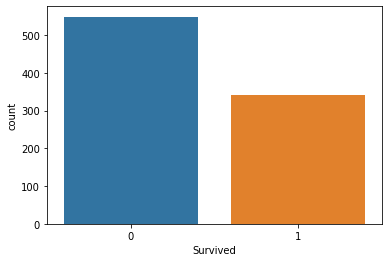

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.countplot(x='Survived', data=train_data)

Как видим, выжило людей меньше, чем погибло.

Теперь посмотрим, как с выживаемостью у мужчин и женщин отдельно.

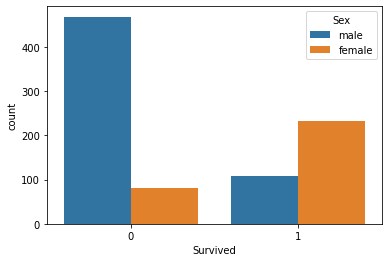

In [ ]:
sns.countplot(x='Survived', hue='Sex', data=train_data)

Видим, что мужчин погибло гораздо больше, чем выжило. И большая часть женщин выжила.

Далее взглянем, как зависела выживаемость от класса каюты.

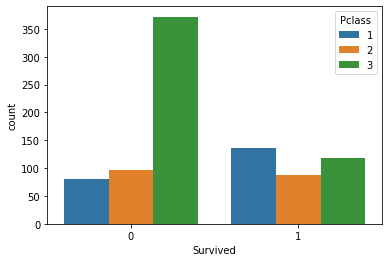

In [ ]:
sns.countplot(x='Survived', hue='Pclass', data=train_data)

Видим всплеск среди погибших пассажиров 3 класса.

Не закапываясь глубоко в датасет, видим явную зависимость выживаемости от пола и класса каюты.

В качестве признаков кроме выбранных пола и класса каюты, возьмем количество родителей\детей и количество братьев\сестер на борту. Итоговый список признаков будет выглядеть следующим образом:

In [ ]:
# список выбранных признаков
features = ['Sex', 'Pclass', 'SibSp', 'Parch']

Информацию о выживших и погибших пассажирах поместим в переменную `y`:

In [ ]:
y = train_data['Survived']

Если вы немного отмотаете назад, то увидите, что в столбце Sex находятся не числа, а строки, когда остальные отобранные нами признаки являются числами. Давайте превратим этот столбец в пару фиктивных переменных. Для этого в Pandas есть специальный метод, который называется get_dummies(). Сделаем эту операцию как для обучающей выборки, так и для тестовой.

In [ ]:
X = pd.get_dummies(train_data[features])
X_test = pd.get_dummies(test_data[features])

Обратите внимание, что столбец Sex исчез, а вместо него появилось два столбца Sex_female и Sex_male.

Теперь с помощью логистической регрессии обучим нашу модель, сделаем предсказание для тестовой выборки и сохраним результат.

## Логистическая регрессия

**Логистическая регрессия** - это статистический метод для анализа набора данных, в котором есть одна или несколько независимых переменных, которые определяют результат. Результат измеряется с помощью дихотомической переменной (в которой есть только два возможных результата). Он используется для прогнозирования двоичного результата (1/0, Да / Нет, Истина / Ложь) с учетом набора независимых переменных.

Вы также можете рассматривать логистическую регрессию как особый случай линейной регрессии, когда исходная переменная является категориальной, где мы используем логарифм шансов в качестве зависимой переменной. Проще говоря, он предсказывает вероятность возникновения события путем подгонки данных к логистической функции.

Помните, что в некоторых случаях зависимые переменные могут иметь более двух результатов, например, в браке / не замужем / в разводе, такие сценарии классифицируются как полиномиальная логистическая регрессия.Хотя они работают одинаково, чтобы предсказать результат.

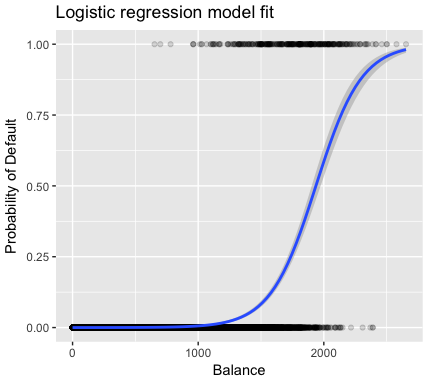

Оптимальные параметры отыскиваются последовательно с помощью итерационного метода наименьших квадратов с использованием взвешивания элементов выборки. Приведенный ниже алгоритм основан на алгоритме Ньютона-Рафсона.

В начале работы алгоритма задаются параметры начального приближения: скаляр $b_0=\log\frac{\tilde{y}}{1-\tilde{y}}$, где $\tilde{y}=\frac{1}{m}\sum_{i=1}^{m}y_i$ - среднее значение выборки зависимой переменной и значения $b_j=0$ для $j=1,\ldots,n.$

Далее итеративно повторяется следующая процедура.

С использованием вектора параметров ${b}$ вычисляется переменная
${z}=X{b}$.
Вычисляется восстановленное значение выборки зависимой переменной
$p=\frac{1}{1+exp({-z})}$.
Вычисляется вектор значений зависимой переменной для текущего шага линейной регрессии
${u} = {z} + \frac{{y}-{p}}{{w}}$,
где
${w} = {p}(1-{p})$ - вектор весов значений зависимой переменной.

Решается задача наименьших квадратов с взвешиванием элементов выборки. При этом
больший вес приобретают те элементы, которые имеют большую невязку

${b} = (X^TWX)^{-1}X^TW{u}$,
где диагональная матрица весов $W =\text{diag}({w})$.

Процедура останавливается после того, как норма разности векторов параметров на каждой итерации не будет превышать заданную константу: $\|{b}^{next}-{b}^{previuos}\|^2 \leq \Delta_{b}$.

In [ ]:
# импортируем класс модели из библиотеки sklearn
from sklearn.linear_model import LogisticRegression

# объявлениe модели
model = LogisticRegression()

# обучаем модель
model.fit(X, y)

# оцениваем точность предсказаний на обучающей выборке
score = round(model.score(X, y) * 100, 2)
print(f'Точность предсказания модели на обучающей выборке: {score} %')


Точность предсказания модели на обучающей выборке: 80.02 %


## Метод k-ближайших соседей

**K-Nearest Neighbors**, или KNN, представляет собой контролируемый алгоритм обучения, который используется преимущественно для решения задач классификации. Данный алгоритм наблюдает за разными центрами (центроидами) и сравнивает расстояние между ними, используя для этого различные функции (обычно евклидово расстояние). Затем определяется, к какому классу принадлежит большинство ближайших объектов обучающей выборки – к этому классу относится и неизвестный объект.

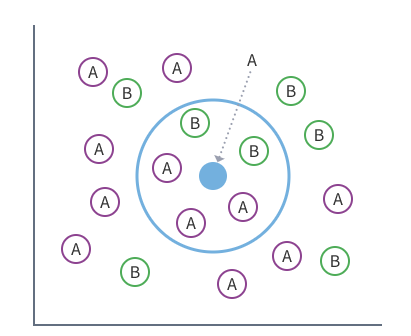

**Алгоритм**

Пусть имеется набор данных, состоящий из nn наблюдений $X_i (i=1,...,n)$, для каждого из которых задан класс $C_j (j=1,...,m)$. Тогда на его основе может быть сформировано обучающее множество, все примеры которого представляют собой пары $\{X_i,C_j\}$.

Алгоритм KNN можно разделить на две простые фазы: обучения и классификации. При обучении алгоритм просто запоминает векторы признаков наблюдений и их метки классов (т.е. примеры). Также задаётся параметр алгоритма $k$, который задаёт число «соседей», которые будут использоваться при классификации.

На фазе классификации предъявляется новый объект, для которого метка класса не задана. Для него определяются $k$ ближайших (в смысле некоторой метрики) предварительно классифицированных наблюдений. Затем выбирается класс, которому принадлежит большинство из $k$ ближайших примеров-соседей, и к этому же классу относится классифицируемый объект.

**Определение класса нового объекта**

В простейшем случае класс нового объекта может быть определён простым выбором наиболее часто встречающегося класса среди $k$ примеров. Однако на практике это не всегда удачное решение, например, в случае когда частота появления для двух или более классов оказывается одинаковой. Кроме этого разумно предположить, что не все обучающие имеют одинаковую значимость для определения класса. В этом случае используют некоторую функцию, с помощью которой определяется класс, называемую функцией сочетания (combination function).

В обычном случае используют так называемое простое невзвешенное голосование (simple unweighted voting). При это предполагается, что все $k$ примеров имеют одинаковое право «голоса» независимо от расстояние до классифицируемого объекта.

Однако, логично предположить, что чем дальше пример расположен от классифицируемого объекта в пространстве признаков, тем ниже его значимость для определения класса. Поэтому для улучшения результатов классификации вводят взвешивание примеров в зависимости от их удалённости. В этом случае используют взвешенное голосование (weighted voting).

В основе идеи взвешенного голосования лежит введение «штрафа» для класса, в зависимости от того, насколько относящиеся к нему примеры удалены от классифицируемого объекта. Такой «штраф» представляется как сумма величин, обратных квадрату расстояний от примера $j$-го класса до классифицируемого объекта (часто данное значение называют показателем близости):

$Q_{j}=\sum\limits_{i=1}^{n_{j}}\frac{1}{D^{2}(x,a_{ij})}$


где $D$ — оператор вычисления расстояния,xx — вектор признаков классифицируемого объекта, $a_{ij}$ — $i$-й пример $j$-го класса. Таким образом, «побеждает» тот класс, для которого величина $Q_j$ окажется наибольшей. При этом также снижается вероятность того, что классы получат одинаковое число голосов.

In [ ]:
# импортируем класс модели из библиотеки sklearn
from sklearn.neighbors import KNeighborsClassifier

# объявлениe модели
model = KNeighborsClassifier()

# обучаем модель
model.fit(X, y)

# оцениваем точность предсказаний на обучающей выборке
score = round(model.score(X, y) * 100, 2)
print(f'Точность предсказания модели на обучающей выборке: {score} %')


Точность предсказания модели на обучающей выборке: 80.7 %


## Деревья решений


**Метод деревьев решений (decision trees)** — это один из наиболее популярных методов решения задач классификации и прогнозирования. Опыт показывает, что чаще всего данный алгоритм используется именно для классификации. На входе модель принимает набор атрибутов, характеризующих некую сущность, а затем спускается по дереву, тестируя их в зависимости от того, какие значения может принимать целевая функция. Таким образом, классификация каждого нового случая происходит при движении вниз до листа, который и укажет нам значение целевой функции в каждом конкретном случае. Деревья принятия решений становятся все более популярными и могут служить очень сильным инструментом для аналитики данных, особенно в сочетании с простыми методами композиции, такими как случайный лес, бустинг и бэггинг

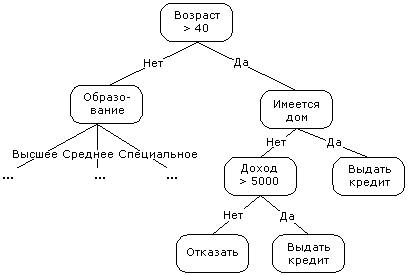

**Алгоритм**

Предлагаем рассмотреть на примере общий алгоритм построения дерева, чтобы затем перейти к его частным случаям:

* Вначале необходимо выбрать атрибут $\large Q$ (допустим: уровень дохода > 500$ в месяц) и поместить его в корневой узел.

* Затем, из наших тестовых примеров (или набора данных) для каждого значения атрибута $\large i$ (например, их два – «да» и «нет») выбираем только те, для которых $\large Q=i$.

* Далее, рекурсивно строим дерево принятия решений.

Основная проблема, очевидно, кроется в первом шаге – на каком основании выбирается каждый следующий атрибут $\large Q$? На этот вопрос существует несколько ответов в виде частных алгоритмов принятия решений – главными из которых являются алгоритмы *ID3*, *C4.5* и *CART*

**Основные частные алгоритмы**

**ID3.**
В основе этого алгоритма лежит понятие информационной энтропии – то есть, меры неопределенности информации (обратной мере информационной полезности величины). Для того чтобы определить следующий атрибут, необходимо подсчитать энтропию всех неиспользованных признаков относительно тестовых образцов и выбрать тот, для которого энтропия минимальна. Этот атрибут и будет считаться наиболее целесообразным признаком классификации.

**C5.**
Этот алгоритм – усовершенствование предыдущего метода, позволяющее, в частности, «усекать» ветви дерева, если оно слишком сильно «разрастается», а также работать не только с атрибутами-категориями, но и с числовыми. В общем-то, сам алгоритм выполняется по тому же принципу, что и его предшественник; отличие состоит в возможности разбиения области значений независимой числовой переменной на несколько интервалов, каждый из которых будет являться атрибутом. В соответствии с этим исходное множество делится на подмножества. В конечном итоге, если дерево получается слишком большим, возможна обратная группировка – нескольких узлов в один лист. При этом, поскольку перед построением дерева ошибка классификации уже учтена, она не увеличивается.

**CART.**
Алгоритм разработан в целях построения так называемых бинарных деревьев решений – то есть тех деревьев, каждый узел которых при разбиении «дает» только двух потомков. Грубо говоря, алгоритм действует путем разделения на каждом шаге множества примеров ровно напополам – по одной ветви идут те примеры, в которых правило выполняется (правый потомок), по другой – те, в которых правило не выполняется (левый потомок). Таким образом, в процессе «роста» на каждом узле дерева алгоритм проводит перебор всех атрибутов, и выбирает для следующего разбиения тот, который максимизирует значение показателя, вычисляемого по математической формуле и зависящего от отношений числа примеров в правом и левом потомке к общему числу примеров.

In [ ]:
# импортируем класс модели из библиотеки sklearn
from sklearn.tree import DecisionTreeClassifier

# объявлениe модели
model = DecisionTreeClassifier()

# обучаем модель
model.fit(X, y)

# оцениваем точность предсказаний на обучающей выборке
score = round(model.score(X, y) * 100, 2)
print(f'Точность предсказания модели на обучающей выборке: {score} %')


Точность предсказания модели на обучающей выборке: 81.71 %


## Случайный лес

**Случайный лес** — популярный алгоритм контролируемого обучения, заключающийся в использовании комитета (ансамбля) решающих деревьев. «Ансамбль» означает, что он берет кучу «слабых учеников» и объединяет их, чтобы сформировать один сильный предиктор. «Слабые ученики» — это все случайные реализации деревьев решений, которые объединяются для формирования сильного предсказателя — случайного леса.

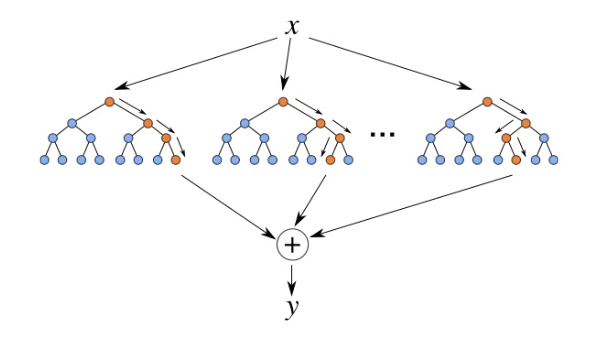

Решающие деревья являются хорошим семейством базовых классификаторов, поскольку они достаточно сложны и могут достигать нулевой ошибки на любой выборке. Метод случайных подпространств позволяет снизить коррелированность между деревьями и избежать переобучения. Базовые алгоритмы обучаются на различных подмножествах признакового описания, которые также выделяются случайным образом.
Ансамбль моделей, использующих метод случайного подпространства, можно построить, используя следующий алгоритм:

Пусть количество объектов для обучения равно $\large N$, а количество признаков $\large D$.
Выберите $\large L$ как число отдельных моделей в ансамбле.
Для каждой отдельной модели $\large l$ выберите $\large dl (dl < D) $ как число признаков для $\large l$. Обычно для всех моделей используется только одно значение $\large dl$.
Для каждой отдельной модели $\large l$ создайте обучающую выборку, выбрав $\large dl$ признаков из $\large D$, и обучите модель.
Теперь, чтобы применить модель ансамбля к новому объекту, объедините результаты отдельных $\large L$ моделей мажоритарным голосованием или путем комбинирования апостериорных вероятностей.

**Алгоритм**

Алгоритм построения случайного леса, состоящего из $\large N$ деревьев, выглядит следующим образом:


* Для каждого $\large n = 1, \dots, N$:

  * Сгенерировать выборку $\large X_n$ с помощью бутстрэпа;

  * Построить решающее дерево $\large b_n$ по выборке $\large X_n$:

    — по заданному критерию мы выбираем лучший признак, делаем разбиение в дереве по нему и так до исчерпания выборки

    — дерево строится, пока в каждом листе не более $\large n_\text{min}$ объектов или пока не достигнем определенной высоты дерева

    — при каждом разбиении сначала выбирается $\large m$ случайных признаков из $\large n$ исходных, и оптимальное разделение выборки ищется только среди них.

Итоговый классификатор $\large a(x) = \frac{1}{N}\sum_{i = 1}^N b_i(x)$, простыми словами — для задачи кассификации мы выбираем решение голосованием по большинству, а в задаче регрессии — средним.


Рекомендуется в задачах классификации брать $\large m = \sqrt{n}$, а в задачах регрессии — $\large m = \frac{n}{3}$, где $\large n$ — число признаков. Также рекомендуется в задачах классификации строить каждое дерево до тех пор, пока в каждом листе не окажется по одному объекту, а в задачах регрессии — пока в каждом листе не окажется по пять объектов.

In [ ]:
# импортируем класс модели из библиотеки sklearn
from sklearn.ensemble import RandomForestClassifier

# объявлениe модели
model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=1)

# обучаем модель
model.fit(X, y)

# оцениваем точность предсказаний на обучающей выборке
score = round(model.score(X, y) * 100, 2)
print(f'Точность предсказания модели на обучающей выборке: {score} %')


Точность предсказания модели на обучающей выборке: 81.59 %


## Метод опорных векторов (SVM)

**Метод опорных векторов**, также известный как SVM, является широко известным алгоритмом классификации, который создает разделительную линию между разными категориями данных. Как этот вектор вычисляется, можно объяснить простым языком — это всего лишь оптимизация линии таким образом, что ближайшие точки в каждой из групп будут наиболее удалены друг от друга.

Этот вектор установлен по умолчанию и часто визуализируется как линейный, однако это не всегда так. Вектор также может принимать нелинейный вид, если тип ядра изменен от типа (по умолчанию) «гауссовского» или линейного.

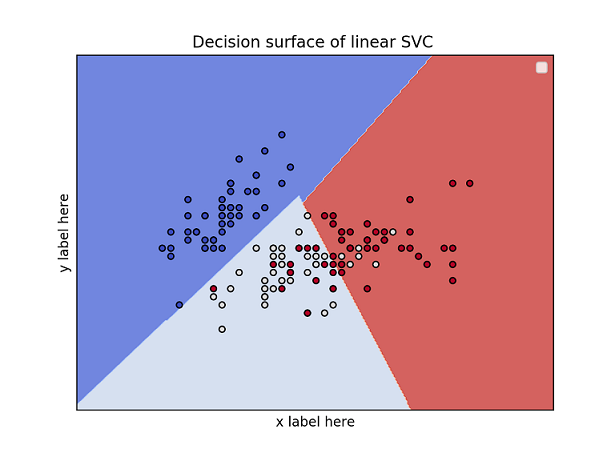

Основной принцип SVM заключается в том, что мы хотим нарисовать гиперплоскость с максимальным отступом, разделяющим два класса. Предположим, мы хотим разделить два класса C1 и C2 с помощью SVC в двумерном пространстве. Затем мы хотим предсказать класс неизвестного вектора признаков X как класс C1 или класс C2.

Мы можем использовать линейное уравнение:

$g(x) = w^TX+b=0 $

$w$ - обозначает вектор веса, перпендикулярный гиперплоскости. Он представляет ориентацию гиперплоскости в $d$-мерном пространстве, где $d$ - размерность вектора признаков.

$b$ - представляет положение гиперплоскости в d-мерном пространстве.

Это линейное уравнение в двух измерениях представляет собой прямую линию. Оно представляет собой плоскость в трехмерном пространстве и гиперплоскость в более чем трех измерениях.

Переходя к проблеме классификации. Для каждого вектора признаков мы должны вычислить линейную функцию таким образом, чтобы:

* Если вектор признаков лежит на положительной стороне гиперплоскости,
  
  $g(X_i) = w^TX_i+b>0 $

* Если вектор признаков лежит на отрицательной  стороне гиперплоскости,
  
  $g(X_i) = w^TX_i+b<0 $.

Правило классификации:

$g(X_i) = w^TX_i+b>0 \Rightarrow X_i \in C1 $

$g(X_i) = w^TX_i+b<0 \Rightarrow X_i \in C2 $

In [ ]:
# импортируем класс модели из библиотеки sklearn
from sklearn.svm import SVC

# объявлениe модели
model = SVC()

# обучаем модель
model.fit(X, y)

# оцениваем точность предсказаний на обучающей выборке
score = round(model.score(X, y) * 100, 2)
print(f'Точность предсказания модели на обучающей выборке: {score} %')


Точность предсказания модели на обучающей выборке: 80.58 %
